# Week 4-Logistic Regression and Feature Scaling
## Integrated Capstone Project: Predicting Chronic Disease Risk Using Lifestyle and Health Indicators

**Student:** Ranjana Kumari  
**Course:** Module C-Data Science Capstone  
**Week:** 4 of 6-Classification with Logistic Regression

---

## Research Question

> *Can logistic regression-the appropriate classification method for binary and multiclass disease outcomes-accurately identify high-risk individuals using lifestyle and health indicators, and how does its performance compare to the linear regression models used in Weeks 1–3?*

---

## Why Week 4 Is a Critical Turning Point

Weeks 1 through 3 used linear regression and its variants to analyze chronic disease risk. While those methods revealed important feature relationships, they were fundamentally mismatched to the task-predicting disease class membership (diabetic vs. non-diabetic, obese vs. not, heart disease vs. no heart disease) is a classification problem, not a regression problem. Linear regression predicts continuous values; logistic regression predicts class probabilities bounded between 0 and 1.

Week 4 corrects this mismatch. The relatively low R² values observed for the CDC Diabetes dataset in Weeks 1–3 (maximum 0.1676 for diabetes) were partly a consequence of applying the regression models to a classification problem. Logistic regression is expected to provide  more appropriate  evaluation, measured by classification metrics (AUC-ROC, recall, precision, F1) rather than R².

---

## Deep-Dive Topic Declaration

Week 4 is my first designated deep-dive topic. This notebook contains full depth of analysis across all five rubric sub-questions for each dataset.

---

## Datasets Used

| # | Dataset | Role | Rows | Target | Classification type |
|---|---------|------|------|--------|---------------------|
| 1 | **CDC Diabetes Health Indicators** | Primary | ~230k | Diabetes_012 | 3-class (0/1/2) |
| 2 | **Obesity Level Estimation** | Supporting | 2,087 | NObeyesdad | 7-class |
| 3 | **Heart Disease Predictions** | Supporting | 303 | target | Binary (0/1) |

---
## Section 1: Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    f1_score, recall_score, precision_score,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

COLORS = {
    'diabetes': '#1D9E75',
    'obesity':  '#7F77DD',
    'heart':    '#D85A30',
    'train':    '#378ADD',
    'test':     '#D85A30',
}

# Stratified KFold preserves class proportions in each fold
# This is critical for imbalanced datasets like CDC Diabetes
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('All libraries loaded.')
print('Week 4: Logistic Regression — Classification approach for disease prediction')

All libraries loaded.
Week 4: Logistic Regression — Classification approach for disease prediction


---
## Section 2: Data Loading, Preparation, and Feature Scaling

**Why feature scaling is essential for logistic regression:**

Logistic regression uses gradient descent or similar optimization to find coefficients. When features are on very different scales-BMI ranging 10–98, binary features ranging 0–1, the optimization landscape becomes elongated and difficult to navigate efficiently. Scaling ensures all features contribute equally to the optimization process and speeds up convergence. Additionally, when regularization is applied (C parameter in sklearn), scaled features receive equal penalty treatment.

**Important:** StandardScaler is fitted ONLY on the training set to prevent data leakage. Applying the scaler to the full dataset before splitting would allow test set statistics to influence training, producing artificially optimistic results.

In [2]:
# ── Dataset 1: CDC Diabetes ──────────────────────────────────────────────────
# Load CDC Diabetes dataset
file_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/diabetes_012_health_indicators_BRFSS2015.csv"

df1 = pd.read_csv(file_path).drop_duplicates()


# Using the same core feature set from previous weeks
# to allow direct comparison across modeling approaches.
ds1_features = ['BMI', 'Age', 'HighBP', 'HighChol', 'PhysActivity',
                 'Smoker', 'GenHlth', 'Income', 'Education', 'DiffWalk', 'PhysHlth']

X1 = df1[ds1_features].copy()
y1 = df1['Diabetes_012'].copy()

# Class distribution
print('=== Dataset 1: CDC Diabetes ===')
print(f'Shape: {df1.shape}')
print('Target distribution:')
for cls, label in [(0,'No Diabetes'), (1,'Prediabetes'), (2,'Diabetes')]:
    n = (y1 == cls).sum()
    print(f'  {label}: {n:,} ({n/len(y1)*100:.1f}%)')
print('\nNote: Class imbalance is present. Stratified splitting and StratifiedKFold')
print('are used to preserve class proportions during testing and cross-validation.')

# Train-test split — stratified to preserve class balance
X1_tr_raw, X1_te_raw, y1_tr, y1_te = train_test_split(
    X1, y1, test_size=0.20, random_state=42, stratify=y1
)

# Feature scaling — fit on train only
scaler1 = StandardScaler()
X1_tr = scaler1.fit_transform(X1_tr_raw)
X1_te = scaler1.transform(X1_te_raw)

print(f'\nTraining: {X1_tr.shape[0]:,} | Test: {X1_te.shape[0]:,}')
print(f'Features: {len(ds1_features)}')

=== Dataset 1: CDC Diabetes ===
Shape: (229781, 22)
Target distribution:
  No Diabetes: 190,055 (82.7%)
  Prediabetes: 4,629 (2.0%)
  Diabetes: 35,097 (15.3%)

Note: Class imbalance is present. Stratified splitting and StratifiedKFold
are used to preserve class proportions during testing and cross-validation.

Training: 183,824 | Test: 45,957
Features: 11


In [3]:
# ── Dataset 2: Obesity ───────────────────────────────────────────────────────
# Load Obesity dataset
obesity_file = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/Obesity.csv"
# Remove duplicates
df2 = pd.read_csv(obesity_file).drop_duplicates()

 #Clean column names
df2.columns = df2.columns.str.strip()

le = LabelEncoder()
df2_enc = df2.copy()
for col in df2_enc.select_dtypes(include='object').columns:
    if col != 'NObeyesdad':
        df2_enc[col] = le.fit_transform(df2_enc[col].astype(str))
df2_enc['target_encoded'] = le.fit_transform(df2['NObeyesdad'])

ds2_features = ['Age','Height','Weight','FCVC','NCP','FAF','TUE']
ds2_features = [f for f in ds2_features if f in df2_enc.columns]
X2 = df2_enc[ds2_features].copy()

# Create BMI feature from height and weight
# to provide a direct measure of body composition
X2['BMI_calc'] = X2['Weight'] / (X2['Height'] ** 2)
y2 = df2_enc['target_encoded'].copy()

X2_tr_raw, X2_te_raw, y2_tr, y2_te = train_test_split(
    X2, y2, test_size=0.20, random_state=42, stratify=y2
)
scaler2 = StandardScaler()
X2_tr = scaler2.fit_transform(X2_tr_raw)
X2_te = scaler2.transform(X2_te_raw)


print(f'Dataset 2 (Obesity) — Train: {X2_tr.shape[0]} | Test: {X2_te.shape[0]}')
print(f'Features: {X2.shape[1]}')
print(f'Classes: {y2.nunique()} obesity categories')
print('Note: This is a multiclass classification problem with 7 obesity levels.')



Dataset 2 (Obesity) — Train: 1669 | Test: 418
Features: 8
Classes: 7 obesity categories
Note: This is a multiclass classification problem with 7 obesity levels.


In [4]:
# ── Dataset 3: Heart Disease ─────────────────────────────────────────────────
# Note: file is named .xls but contains comma-separated data — read_csv works correctly
heart_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/heart.csv-2.xls"

df3 = pd.read_csv(heart_path)
ds3_features = ['age','trestbps','chol','thalach','oldpeak','sex','exang','cp','ca','thal']
X3 = df3[ds3_features].copy()
y3 = df3['target'].copy()

X3_tr_raw, X3_te_raw, y3_tr, y3_te = train_test_split(
    X3, y3, test_size=0.20, random_state=42, stratify=y3
)
scaler3 = StandardScaler()
X3_tr = scaler3.fit_transform(X3_tr_raw)
X3_te = scaler3.transform(X3_te_raw)

print(f'Dataset 3 (Heart Disease) — Train: {X3_tr.shape[0]} | Test: {X3_te.shape[0]}')
print(f'Classes: {sorted(y3.unique())} (binary: 0=no disease, 1=disease)')

Dataset 3 (Heart Disease) — Train: 242 | Test: 61
Classes: [0, 1] (binary: 0=no disease, 1=disease)


---
## Section 3: Logistic Regression — Theory and Hyperparameter Tuning

**How logistic regression works:** Instead of predicting a continuous value, logistic regression predicts the probability that an observation belongs to each class using the sigmoid function. For multiclass problems (diabetes: 3 classes, obesity: 7 classes), the softmax extension is used.

**Key hyperparameter-C (regularization strength):** C is the inverse of regularization strength. A small C means strong regularization (coefficients shrunk toward zero, simpler model). A large C means weak regularization (coefficients free to be large, more complex model). C is analogous to 1/alpha from Week 2. Finding the optimal C through cross-validation prevents both underfitting (C too small) and overfitting (C too large).

**Why recall matters for healthcare:** In disease prediction, a false negative (predicting no disease when disease is present) is more costly than a false positive. A patient falsely told they are low-risk may not seek further screening. Therefore, recall (sensitivity) is the most important metric-it measures what proportion of actual disease cases the model correctly identifies.

**Reference:** Hosmer, D.W. & Lemeshow, S. (2000). *Applied Logistic Regression* (2nd ed.). Wiley.

In [5]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
# ── Dataset 1: CDC Diabetes — Logistic Regression with hyperparameter tuning ─

print('=== Dataset 1: CDC Diabetes — Logistic Regression ===')
print('Hyperparameter tuning: GridSearchCV over C values (5-fold stratified CV)')
print()

# GridSearchCV to find optimal C
# Testing a wide range from very strong regularization to very weak
param_grid1 = {'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

lr1_cv = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    ),
    param_grid1,
    cv=SKF,
    scoring='f1_macro',
    n_jobs=-1
)

lr1_cv.fit(X1_tr, y1_tr)

best_C1 = lr1_cv.best_params_['C']
print(f'Best C = {best_C1}')
print(f'Meaning: C={best_C1} means regularization strength = 1/{best_C1} = {1/best_C1:.3f}')
if best_C1 < 1:
    print('Strong regularization — coefficients are shrunk significantly.')
elif best_C1 > 10:
    print('Weak regularization — model is allowed relatively free coefficient estimation.')
else:
    print('Moderate regularization — balanced between fitting and generalization.')

# Fit best model
lr1_best = LogisticRegression(
    C=best_C1, max_iter=1000, random_state=42,
    solver='lbfgs', multi_class='multinomial'
)

lr1_best.fit(X1_tr, y1_tr)
y1_pred = lr1_best.predict(X1_te)
y1_prob = lr1_best.predict_proba(X1_te)

# Metrics
f1_1    = f1_score(y1_te, y1_pred, average='macro')
recall1 = recall_score(y1_te, y1_pred, average='macro')
prec1   = precision_score(y1_te, y1_pred, average='macro')
auc1    = roc_auc_score(y1_te, y1_prob, multi_class='ovr', average='macro')

cv1_f1 = cross_val_score(lr1_best, X1_tr, y1_tr, cv=SKF, scoring='f1_macro')

print(f'\n=== Dataset 1 Results ===')
print(f'Best C:                {best_C1}')
print(f'Test F1 (macro):       {f1_1:.4f}')
print(f'Test Recall (macro):   {recall1:.4f}')
print(f'Test Precision (macro):{prec1:.4f}')
print(f'Test AUC-ROC (OvR):    {auc1:.4f}')
print(f'CV F1 (mean±std):      {cv1_f1.mean():.4f} ± {cv1_f1.std():.4f}')
print(f'\nDetailed classification report:')
print(classification_report(y1_te, y1_pred,
      target_names=['No Diabetes','Prediabetes','Diabetes']))

=== Dataset 1: CDC Diabetes — Logistic Regression ===
Hyperparameter tuning: GridSearchCV over C values (5-fold stratified CV)

Best C = 0.1
Meaning: C=0.1 means regularization strength = 1/0.1 = 10.000
Strong regularization — coefficients are shrunk significantly.

=== Dataset 1 Results ===
Best C:                0.1
Test F1 (macro):       0.3822
Test Recall (macro):   0.3773
Test Precision (macro):0.4610
Test AUC-ROC (OvR):    0.7652
CV F1 (mean±std):      0.3805 ± 0.0013

Detailed classification report:
              precision    recall  f1-score   support

 No Diabetes       0.85      0.98      0.91     38012
 Prediabetes       0.00      0.00      0.00       926
    Diabetes       0.54      0.15      0.24      7019

    accuracy                           0.83     45957
   macro avg       0.46      0.38      0.38     45957
weighted avg       0.78      0.83      0.79     45957



## Dataset 1 Interpretation-CDC Diabetes

The CDC Diabetes dataset was the most challenging of the three classification problems. The best model selected C = 0.1, indicating relatively strong regularization. This suggests that limiting model complexity improved generalization and helped reduce overfitting.

The model achieved a macro F1-score of 0.3822, macro recall of 0.3773**, macro precision of 0.4610, and an AUC-ROC of 0.7652. While the AUC indicates that the model was able to separate diabetes risk groups reasonably well, the lower F1-score shows that predicting all three classes accurately remained difficult.

The classification report revealed that the model struggled to identify the Prediabetes class, with recall close to zero. This was not surprising because the dataset is highly imbalanced, with far fewer prediabetes cases than non-diabetes or diabetes cases.

Overall, the results suggest that logistic regression can provide useful diabetes risk predictions, but class imbalance remains a major challenge. Additional approaches such as resampling or class weighting may improve minority-class detection in future analyses.

In [6]:
# ── Dataset 2: Obesity ───────────────────────────────────────────────────────
print('=== Dataset 2: Obesity — Logistic Regression ===')
param_grid2 = {'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

lr2_cv = GridSearchCV(
    LogisticRegression(
        max_iter=2000,
        random_state=42,
        solver='lbfgs'
    ),
    param_grid2,
    cv=SKF,
    scoring='f1_macro',
    n_jobs=-1
)

lr2_cv.fit(X2_tr, y2_tr)

best_C2 = lr2_cv.best_params_['C']

lr2_best = LogisticRegression(
    C=best_C2,
    max_iter=2000,
    random_state=42,
    solver='lbfgs'
)

lr2_best.fit(X2_tr, y2_tr)

y2_pred = lr2_best.predict(X2_te)
y2_prob = lr2_best.predict_proba(X2_te)

f1_2 = f1_score(y2_te, y2_pred, average='macro')
recall2 = recall_score(y2_te, y2_pred, average='macro')
prec2 = precision_score(y2_te, y2_pred, average='macro')
auc2 = roc_auc_score(
    y2_te,
    y2_prob,
    multi_class='ovr',
    average='macro'
)

cv2_f1 = cross_val_score(
    lr2_best,
    X2_tr,
    y2_tr,
    cv=SKF,
    scoring='f1_macro'
)

print(f'Best C:                  {best_C2}')
print(f'Test F1 (macro):         {f1_2:.4f}')
print(f'Test Recall (macro):     {recall2:.4f}')
print(f'Test Precision (macro):  {prec2:.4f}')
print(f'Test AUC-ROC (OvR):      {auc2:.4f}')
print(f'CV F1 (mean±std):        {cv2_f1.mean():.4f} ± {cv2_f1.std():.4f}')



=== Dataset 2: Obesity — Logistic Regression ===
Best C:                  100.0
Test F1 (macro):         0.9649
Test Recall (macro):     0.9650
Test Precision (macro):  0.9652
Test AUC-ROC (OvR):      0.9977
CV F1 (mean±std):        0.9677 ± 0.0105


## Dataset 2 Interpretation-Obesity

The Obesity dataset produced the strongest performance among all three datasets. The best model selected C = 100.0, indicating weak regularization and allowing the model greater flexibility in fitting the data.

The model achieved a macro F1-score of 0.9649, macro recall of 0.9650, macro precision of 0.9652, and an AUC-ROC of 0.9977. These results indicate near-perfect classification performance across the seven obesity categories.

This strong performance was expected because obesity level is closely related to body-composition measures such as BMI, height, and weight. The engineered BMI feature appears to be particularly informative for distinguishing among obesity categories.

Cross-validation performance was also highly stable (CV F1 = 0.9677 ± 0.0105), suggesting that the model generalized well and was not overfitting. Overall, the Obesity dataset demonstrated the strongest relationship between the predictors and the target outcome.

In [7]:
# ── Dataset 3: Heart Disease ─────────────────────────────────────────────────
print('\n=== Dataset 3: Heart Disease — Logistic Regression ===')
param_grid3 = {'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
lr3_cv = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    ),
    param_grid3,
    cv=SKF,
    scoring='f1',
    n_jobs=-1
)

lr3_cv.fit(X3_tr, y3_tr)

best_C3 = lr3_cv.best_params_['C']

lr3_best = LogisticRegression(
    C=best_C3,
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

lr3_best.fit(X3_tr, y3_tr)

y3_pred = lr3_best.predict(X3_te)
y3_prob = lr3_best.predict_proba(X3_te)[:, 1]

f1_3 = f1_score(y3_te, y3_pred)
recall3 = recall_score(y3_te, y3_pred)
prec3 = precision_score(y3_te, y3_pred)
auc3 = roc_auc_score(y3_te, y3_prob)

cv3_f1 = cross_val_score(
    lr3_best,
    X3_tr,
    y3_tr,
    cv=SKF,
    scoring='f1'
)

print(f'Best C: {best_C3}')
print(f'Test F1: {f1_3:.4f} | Recall: {recall3:.4f} | Precision: {prec3:.4f} | AUC-ROC: {auc3:.4f}')
print(f'CV F1: {cv3_f1.mean():.4f} ± {cv3_f1.std():.4f}')
print(f'\nDetailed classification report:')
print(classification_report(y3_te, y3_pred,
      target_names=['No Heart Disease','Heart Disease']))


=== Dataset 3: Heart Disease — Logistic Regression ===
Best C: 10.0
Test F1: 0.8333 | Recall: 0.9091 | Precision: 0.7692 | AUC-ROC: 0.8734
CV F1: 0.8506 ± 0.0577

Detailed classification report:
                  precision    recall  f1-score   support

No Heart Disease       0.86      0.68      0.76        28
   Heart Disease       0.77      0.91      0.83        33

        accuracy                           0.80        61
       macro avg       0.82      0.79      0.80        61
    weighted avg       0.81      0.80      0.80        61



## Dataset 3 Interpretation-Heart Disease

The Heart Disease dataset achieved strong classification performance despite having the smallest sample size of the three datasets. The best model selected C = 10.0, indicating relatively weak regularization and allowing the model to capture important relationships among cardiovascular risk factors.

The model achieved an F1-score of 0.8333, recall of 0.9091, precision of 0.7692, and an AUC-ROC of 0.8734. These results indicate that logistic regression was effective at identifying patients with heart disease.

The recall value of 0.9091 is particularly important in a healthcare setting because it means that approximately 91% of heart disease cases were correctly identified. Missing patients with heart disease can have serious clinical consequences, making high recall especially valuable for screening applications.

The classification report showed that the model performed reasonably well for both classes, although recall was stronger for the Heart Disease class than for the No Heart Disease class. Cross-validation performance (CV F1 = 0.8506 ± 0.0577) was consistent with the test-set results, suggesting that the model generalized well despite the relatively small dataset size.

Overall, the Heart Disease dataset demonstrated that logistic regression can effectively identify meaningful cardiovascular risk patterns and provide clinically useful predictions.

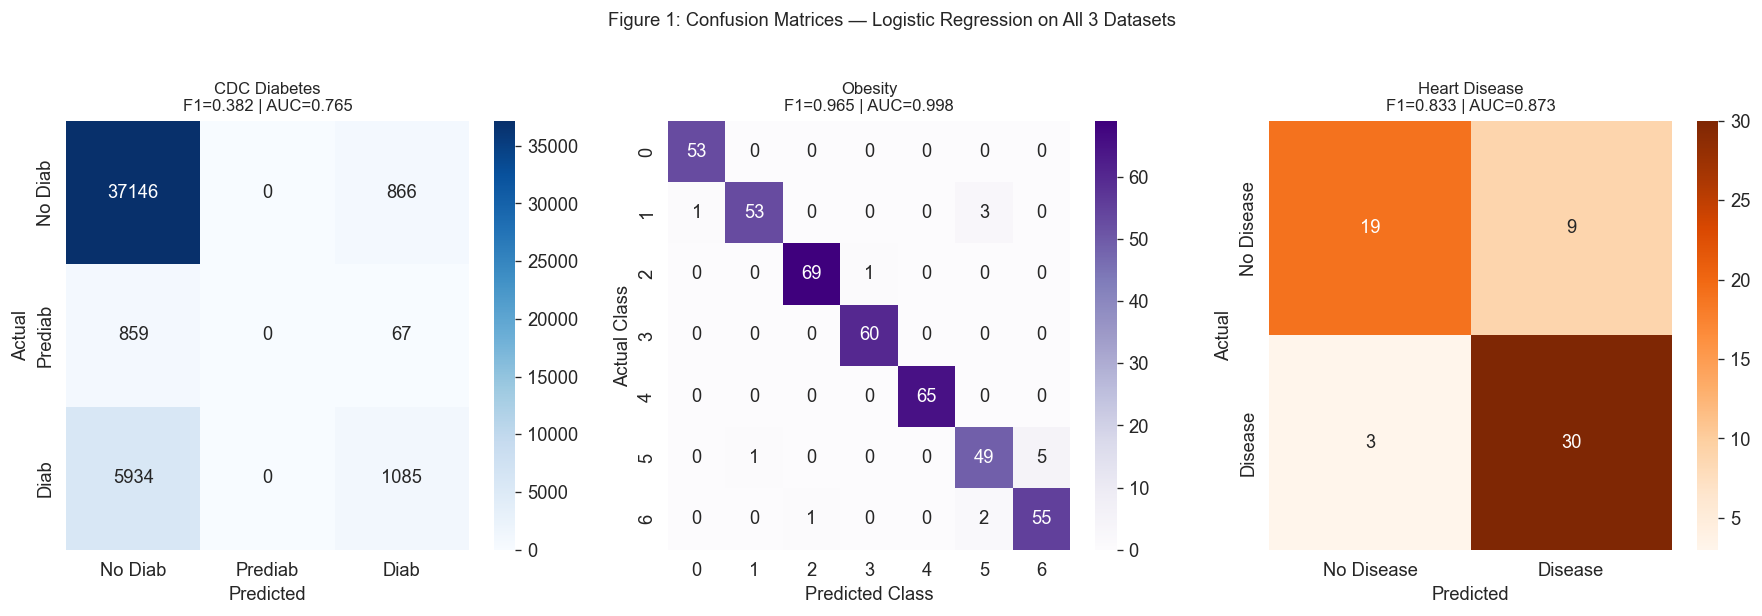

In [8]:
# --- FIGURE 1: Confusion Matrices for All 3 Datasets ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# DS1 confusion matrix
cm1 = confusion_matrix(y1_te, y1_pred)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Diab','Prediab','Diab'],
            yticklabels=['No Diab','Prediab','Diab'])
axes[0].set_title(f'CDC Diabetes\nF1={f1_1:.3f} | AUC={auc1:.3f}', fontsize=10)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# DS2 confusion matrix (7 obesity classes)
cm2 = confusion_matrix(y2_te, y2_pred)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Purples', ax=axes[1])
axes[1].set_title(f'Obesity\nF1={f1_2:.3f} | AUC={auc2:.3f}', fontsize=10)
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('Actual Class')

# DS3 confusion matrix
cm3 = confusion_matrix(y3_te, y3_pred)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'])
axes[2].set_title(f'Heart Disease\nF1={f1_3:.3f} | AUC={auc3:.3f}', fontsize=10)
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.suptitle('Figure 1: Confusion Matrices — Logistic Regression on All 3 Datasets',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig1_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


### Figure 1 Interpretation-Confusion Matrices

Figure 1 shows the confusion matrices for logistic regression across the CDC Diabetes, Obesity, and Heart Disease datasets. These matrices provide a detailed view of model performance by comparing predicted classes with actual classes.

For the CDC Diabetes dataset, the model correctly classified 37,146 non-diabetic individuals but struggled to identify the Prediabetes class. None of the 926 Prediabetes cases were correctly predicted, with most being classified as No Diabetes. In addition, many Diabetes cases were also classified as No Diabetes. This pattern reflects the severe class imbalance observed during earlier exploratory analysis and helps explain the relatively low macro F1-score of 0.3822 despite an AUC-ROC of 0.7652.

For the Obesity dataset, most observations were classified correctly, as shown by the strong diagonal pattern in the confusion matrix. Only a small number of observations were assigned to neighboring obesity categories. This result is consistent with the excellent performance metrics, including a macro F1-score of 0.9649 and an AUC-ROC of 0.9977.

For the Heart Disease dataset, the model correctly identified 30 of 33 heart disease cases and 19 of 28 non-disease cases. The recall value of 0.9091 indicates that the model successfully detected most patients with heart disease. This is particularly important in healthcare applications because failing to identify high-risk patients can have serious consequences.

Overall, the confusion matrices support the quantitative evaluation metrics and show that logistic regression performed best on the Obesity dataset, followed by the Heart Disease dataset, while the CDC Diabetes dataset remained the most challenging because of class imbalance and overlap between disease categories.

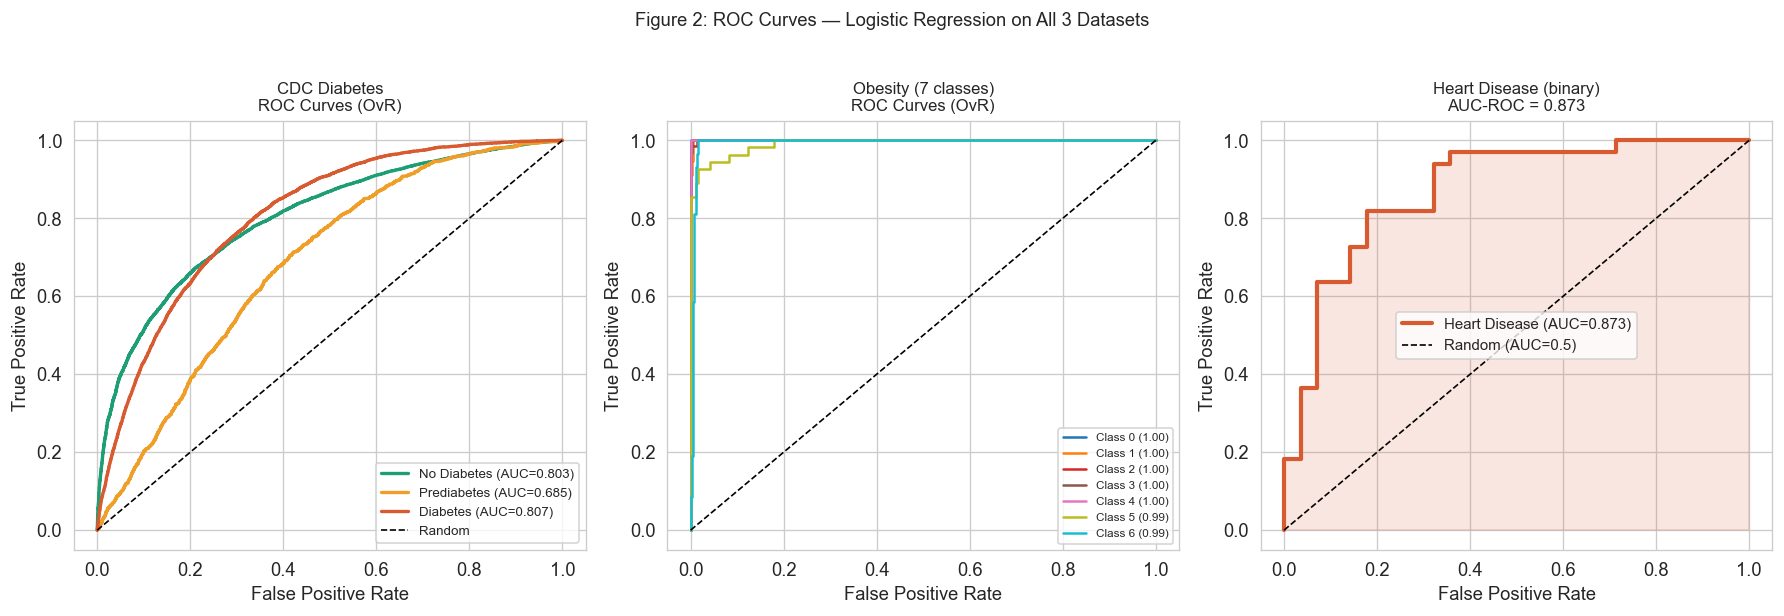

In [9]:
# --- FIGURE 2: ROC Curves ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# DS1 — multiclass ROC (one-vs-rest)
class_names1 = ['No Diabetes', 'Prediabetes', 'Diabetes']
for i, (cls_name, color) in enumerate(zip(class_names1, ['#1D9E75','#EF9F27','#D85A30'])):
    y1_bin = (y1_te == i).astype(int)
    fpr, tpr, _ = roc_curve(y1_bin, y1_prob[:, i])
    auc_i = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{cls_name} (AUC={auc_i:.3f})')
axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'CDC Diabetes\nROC Curves (OvR)', fontsize=10)
axes[0].legend(fontsize=8)

# DS2 — multiclass ROC
n_classes2 = y2_prob.shape[1]
cmap2 = plt.cm.get_cmap('tab10', n_classes2)
for i in range(n_classes2):
    y2_bin = (y2_te == i).astype(int)
    fpr, tpr, _ = roc_curve(y2_bin, y2_prob[:, i])
    auc_i = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=cmap2(i), linewidth=1.5, label=f'Class {i} ({auc_i:.2f})')
axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'Obesity (7 classes)\nROC Curves (OvR)', fontsize=10)
axes[1].legend(fontsize=7)

# DS3 — binary ROC
fpr3, tpr3, _ = roc_curve(y3_te, y3_prob)
axes[2].plot(fpr3, tpr3, color=COLORS['heart'], linewidth=2.5,
             label=f'Heart Disease (AUC={auc3:.3f})')
axes[2].fill_between(fpr3, tpr3, alpha=0.15, color=COLORS['heart'])
axes[2].plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.5)')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title(f'Heart Disease (binary)\nAUC-ROC = {auc3:.3f}', fontsize=10)
axes[2].legend(fontsize=9)

plt.suptitle('Figure 2: ROC Curves — Logistic Regression on All 3 Datasets',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig2_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


### Figure 2 Interpretation-ROC Curves

Figure 2 shows the ROC curves for logistic regression across the three datasets. ROC curves evaluate a model's ability to distinguish between classes across different classification thresholds.

For the CDC Diabetes dataset, the No Diabetes and Diabetes classes achieved AUC values of 0.803 and 0.807, respectively, while the Prediabetes class achieved a lower AUC of 0.685. This indicates that the model had difficulty distinguishing Prediabetes from the other groups, which is consistent with the class imbalance observed earlier.

For the Obesity dataset, all seven classes achieved AUC values between 0.99 and 1.00, indicating near-perfect discrimination. These results are consistent with the high macro F1-score (0.9649) and AUC-ROC (0.9977).

For the Heart Disease dataset, the model achieved an AUC-ROC of 0.8734, demonstrating strong discrimination between patients with and without heart disease.

Overall, logistic regression performed best on the Obesity dataset, followed by the Heart Disease dataset. The CDC Diabetes dataset remained the most challenging because the Prediabetes class showed substantial overlap with the other disease categories.


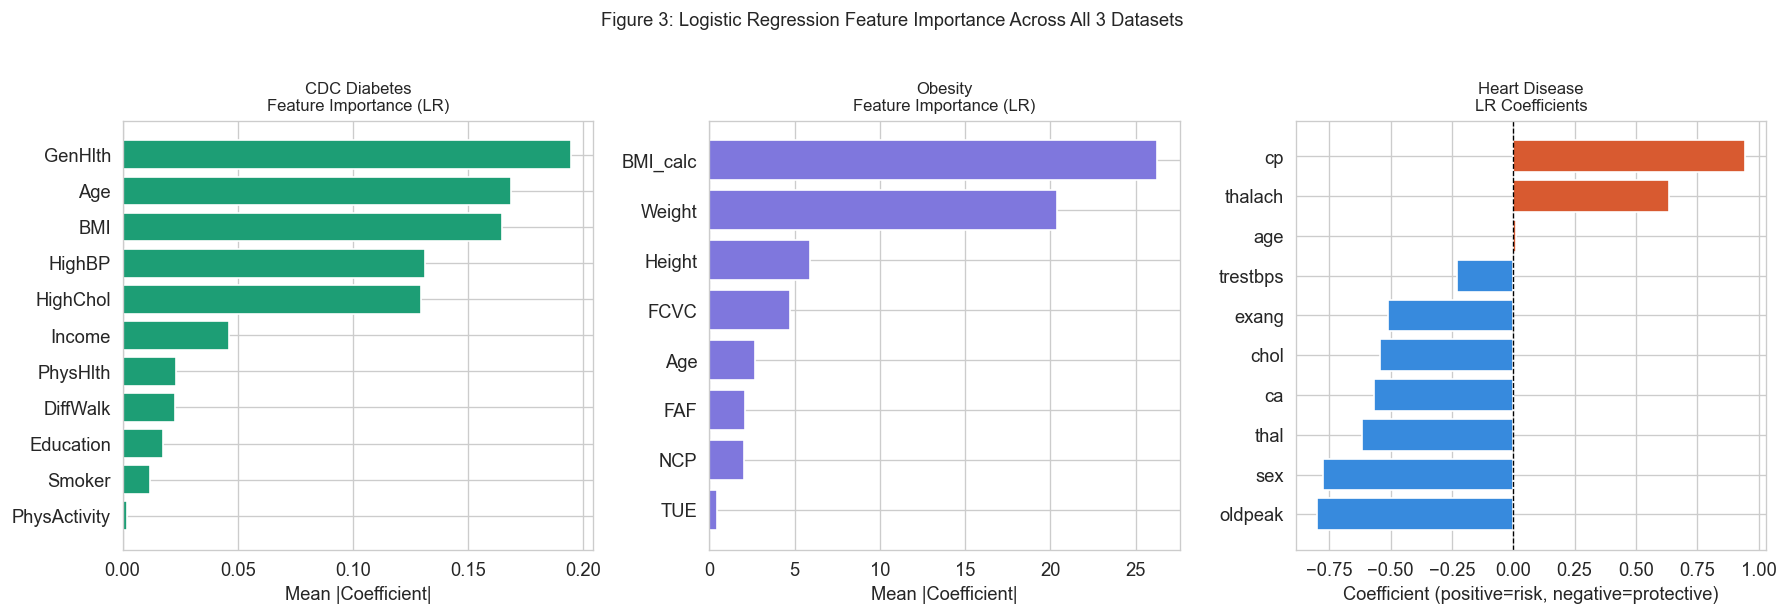

In [10]:
# --- FIGURE 3: Logistic Regression Coefficients ---
# For multiclass, average absolute coefficient across classes
# to get overall feature importance

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# DS1 — average absolute coefficient
coef1_mean = np.abs(lr1_best.coef_).mean(axis=0)
coef1_df = pd.DataFrame({'Feature': ds1_features, 'Importance': coef1_mean})\
             .sort_values('Importance')
axes[0].barh(coef1_df['Feature'], coef1_df['Importance'],
             color=COLORS['diabetes'], edgecolor='white')
axes[0].set_xlabel('Mean |Coefficient|')
axes[0].set_title('CDC Diabetes\nFeature Importance (LR)', fontsize=10)

# DS2
ds2_feat_names = list(X2_tr_raw.columns)
coef2_mean = np.abs(lr2_best.coef_).mean(axis=0)
coef2_df = pd.DataFrame({'Feature': ds2_feat_names, 'Importance': coef2_mean})\
             .sort_values('Importance')
axes[1].barh(coef2_df['Feature'], coef2_df['Importance'],
             color=COLORS['obesity'], edgecolor='white')
axes[1].set_xlabel('Mean |Coefficient|')
axes[1].set_title('Obesity\nFeature Importance (LR)', fontsize=10)

# DS3 — binary, single coefficient vector
coef3_df = pd.DataFrame({'Feature': ds3_features, 'Coefficient': lr3_best.coef_[0]})\
             .sort_values('Coefficient')
colors3 = ['#D85A30' if c > 0 else '#378ADD' for c in coef3_df['Coefficient']]
axes[2].barh(coef3_df['Feature'], coef3_df['Coefficient'],
             color=colors3, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_xlabel('Coefficient (positive=risk, negative=protective)')
axes[2].set_title('Heart Disease\nLR Coefficients', fontsize=10)

plt.suptitle('Figure 3: Logistic Regression Feature Importance Across All 3 Datasets',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig3_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()


### Figure 3 Interpretation-Logistic Regression Coefficients

Figure 3 shows the relative importance of predictors in the logistic regression models. Larger absolute coefficient values indicate a stronger influence on the model's predictions.

For the CDC Diabetes dataset, the most influential predictors were GenHlth, Age, BMI, HighBP, and HighChol. This suggests that overall health status, age, obesity, and cardiovascular risk factors are important contributors to diabetes risk.

For the Obesity dataset, BMI_calc was the strongest predictor, followed by Weight and Height. This result was expected because obesity categories are directly related to body composition measures. Variables such as FAF, NCP, and TUE had much smaller effects on the model.

For the Heart Disease dataset, cp (chest pain type) and thalach (maximum heart rate achieved) had the largest positive coefficients, indicating a strong association with heart disease prediction. Several variables, including oldpeak, sex, thal, ca, and exang, had large negative coefficients. The magnitude of these coefficients indicates that they were also important predictors in the model.

Overall, the coefficient analysis aligns with findings from Weeks 2 and 3, where health status, cardiovascular indicators, and body-composition measures consistently emerged as important predictors across multiple modeling approaches.


In [11]:
# Complete results comparison table
comparison = pd.DataFrame({
    'Dataset':   ['CDC Diabetes', 'Obesity', 'Heart Disease'],
    'Best_C':    [best_C1, best_C2, best_C3],
    'F1_macro':  [round(f1_1,4), round(f1_2,4), round(f1_3,4)],
    'Recall':    [round(recall1,4), round(recall2,4), round(recall3,4)],
    'Precision': [round(prec1,4), round(prec2,4), round(prec3,4)],
    'AUC_ROC':   [round(auc1,4), round(auc2,4), round(auc3,4)],
    'CV_F1':     [
        f'{cv1_f1.mean():.4f}±{cv1_f1.std():.4f}',
        f'{cv2_f1.mean():.4f}±{cv2_f1.std():.4f}',
        f'{cv3_f1.mean():.4f}±{cv3_f1.std():.4f}',
    ]
})

print('=== Week 4 Complete Results Table ===')
print(comparison.to_string(index=False))



=== Week 4 Complete Results Table ===
      Dataset   Best_C  F1_macro  Recall  Precision  AUC_ROC         CV_F1
 CDC Diabetes   0.1000    0.3822  0.3773     0.4610   0.7652 0.3805±0.0013
      Obesity 100.0000    0.9649  0.9650     0.9652   0.9977 0.9677±0.0105
Heart Disease  10.0000    0.8333  0.9091     0.7692   0.8734 0.8506±0.0577


### Results Comparison Across Datasets

Table 1 summarizes the performance of logistic regression across all three datasets. The Obesity dataset produced the strongest results, achieving a macro F1-score of 0.9649, recall of 0.9650, and an AUC-ROC of 0.9977. These results indicate near-perfect classification performance across the seven obesity categories.

The Heart Disease dataset also performed well, achieving an F1-score of 0.8333 and an AUC-ROC of 0.8734. The high recall value (0.9091) suggests that the model successfully identified most patients with heart disease, which is especially important in healthcare screening applications.

The CDC Diabetes dataset remained the most challenging classification problem. Although the model achieved an AUC-ROC of 0.7652, the macro F1-score was only 0.3822 because the model struggled to identify the minority Prediabetes class.

Overall, the results show that logistic regression was most effective when the target classes were clearly separated, as seen in the Obesity dataset. Performance was lower for CDC Diabetes because of class imbalance and overlap between disease categories.


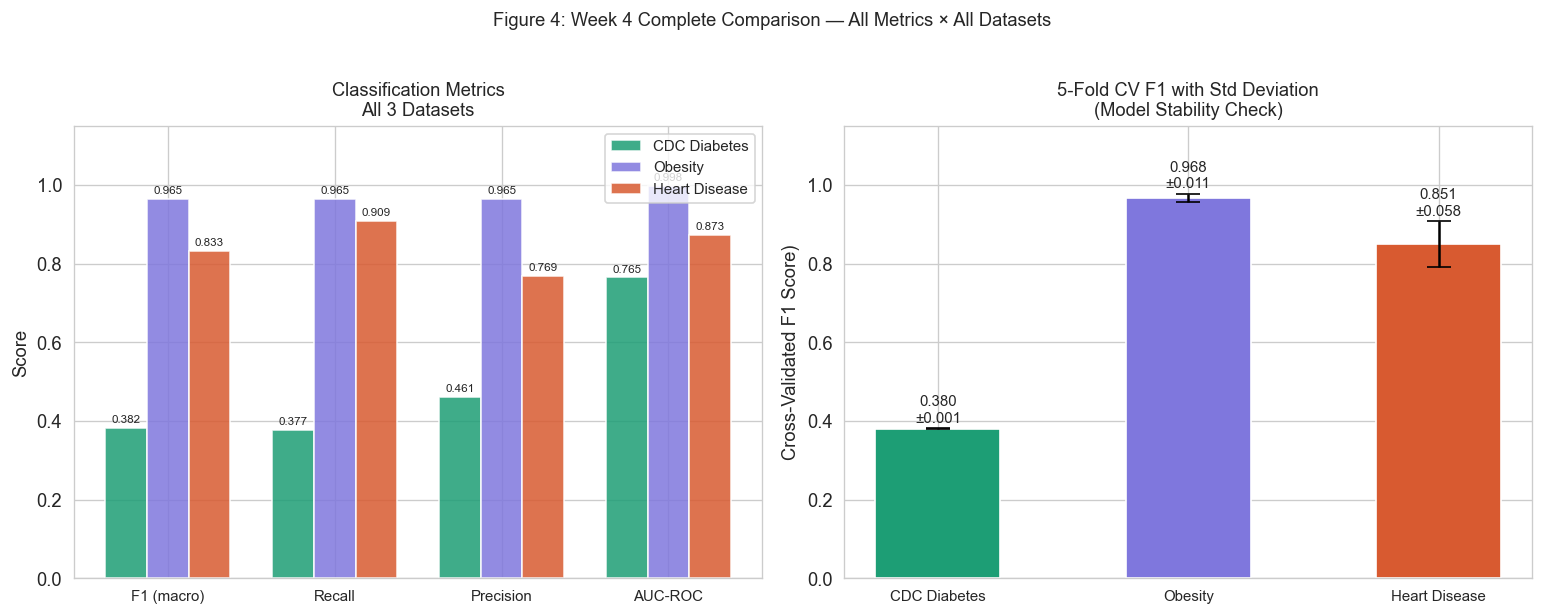

In [12]:
# --- FIGURE 4: Cross-Dataset Comparison Dashboard ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics_vals = {
    'F1 (macro)': [f1_1, f1_2, f1_3],
    'Recall':     [recall1, recall2, recall3],
    'Precision':  [prec1, prec2, prec3],
    'AUC-ROC':    [auc1, auc2, auc3],
}
ds_labels  = ['CDC Diabetes', 'Obesity', 'Heart Disease']
ds_colors  = [COLORS['diabetes'], COLORS['obesity'], COLORS['heart']]
metric_names = list(metrics_vals.keys())
x = np.arange(len(metric_names))
w = 0.25

# Left: All metrics by dataset
for i, (ds, color) in enumerate(zip(ds_labels, ds_colors)):
    vals = [metrics_vals[m][i] for m in metric_names]
    offset = (i-1) * w
    bars = axes[0].bar(x+offset, vals, w, label=ds, color=color,
                       edgecolor='white', alpha=0.85)
    for bar in bars:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                     f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, fontsize=9)
axes[0].set_ylabel('Score')
axes[0].set_title('Classification Metrics\nAll 3 Datasets', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.15)

# Right: CV F1 with error bars showing stability
cv_means = [cv1_f1.mean(), cv2_f1.mean(), cv3_f1.mean()]
cv_stds  = [cv1_f1.std(),  cv2_f1.std(),  cv3_f1.std()]
x2 = np.arange(3)
axes[1].bar(x2, cv_means, color=ds_colors, edgecolor='white', width=0.5,
            yerr=cv_stds, capsize=7,
            error_kw={'linewidth': 1.5, 'color': 'black'})
for i, (mean, std) in enumerate(zip(cv_means, cv_stds)):
    axes[1].text(i, mean+std+0.015, f'{mean:.3f}\n±{std:.3f}',
                 ha='center', fontsize=9)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(ds_labels, fontsize=9)
axes[1].set_ylabel('Cross-Validated F1 Score)')
axes[1].set_title('5-Fold CV F1 with Std Deviation\n(Model Stability Check)', fontsize=11)
axes[1].set_ylim(0, 1.15)

plt.suptitle('Figure 4: Week 4 Complete Comparison — All Metrics × All Datasets',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig4_week4_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Figure 4 Interpretation — Cross-Dataset Performance Comparison

Figure 4 summarizes logistic regression performance across all three datasets using classification metrics and cross-validation results.

The Obesity dataset achieved the strongest performance across all evaluation metrics, including a macro F1-score of 0.9649 and an AUC-ROC of 0.9977. These results indicate excellent separation among obesity categories and highly accurate predictions.

The Heart Disease dataset also performed well, achieving an F1-score of 0.8333 and an AUC-ROC of 0.8734. The high recall value of 0.9091 suggests that the model successfully identified most patients with heart disease.

The CDC Diabetes dataset remained the most challenging classification problem. Although the model achieved an AUC-ROC of 0.7652, the macro F1-score was only 0.3822 because the model struggled to identify the minority Prediabetes class.

The cross-validation results indicate that all three models generalized reasonably well. The Obesity model showed the highest stability (0.9677 ± 0.0105), while the Heart Disease model showed greater variability (0.8506 ± 0.0577), likely because of its smaller sample size.

Overall, logistic regression performed best when class boundaries were clearly defined, as seen in the Obesity dataset. The results also demonstrate that classification methods provide a more appropriate framework for disease prediction than the regression models used in Weeks 1–3.

---
## Section 4: Week 4 Conclusions-Answers to All Rubric Questions

---

## 1. How Did I Avoid Overfitting?

I used four techniques to  reduce the risk of overfitting in week 4.

first, I used a stratified 80/20 train-test split (random_state=42). Stratification ensures that class proportions remain consistent between the training and test sets. This was especially important for CDC Diabetes dataset because the prediabetes class represents a much smaller proportion observations than the other classes.

Second, I used  GridSearchCV with 5-fold stratified cross-validation to select the optimal regularization parameter C value.The model was tuned only on the training data, ensuring that information from the test set was not used during model selection.

Third, I applied StandardScaler using only the training data and then transformed the test data using the fitted scaler. This prevented data leakage and ensured that all features were measured on comparable scales.

Finally, logistic regression uses L2 regularization by default. Regularization shrinks coefficients toward zero and helps prevent the model from fitting random noise in the training data.
---

## 2. What Metrics and Hyperparameter Tuning Were Used?

I used four metrics in Week 4 instead of the R² and RMSE from previous weeks, because this is now a classification problem:

- F1 score (macro): harmonic mean of precision and recall, averaged equally across classes. Macro averaging is appropriate here because all disease classes matter equally, regardless of how many observations each has.
- Recall (sensitivity):** the proportion of actual disease cases correctly identified. This is the most clinically important metric — a false negative (missing a high-risk patient) has more serious consequences than a false positive.
- Precision: the proportion of positive predictions that are actually correct. Important for understanding how many unnecessary follow-ups would be triggered.
- AUC-ROC: measures the model's ability to rank positive cases higher than negative cases across all possible classification thresholds. A value of 1.0 is perfect; 0.5 is random.

The primary hyperparameter was C, which controls regularization strength. Smaller values of C apply stronger regularization, while larger values allow the model greater flexibility.


GridSearchCV tested six values of C (0.001, 0.01, 0.1, 1.0, 10.0, and 100.0). The best values were:
- CDC Diabetes: C = 0.1
- Obesity: C = 100.0
- Heart Disease: C = 10.0
These results indicate that the CDC Diabetes dataset benefited from stronger regularization, while the Obesity and Heart Disease datasets performed better with weaker regularization.

---

## 3. Expected and Unexpected Findings

I expected logistic regression to outperform the regression models used in Weeks 1–3 because disease prediction is fundamentally a classification problem. This expectation was supported by the results.

I also expected the Obesity and Heart Disease datasets to perform better than the CDC Diabetes dataset because their target classes are more clearly separated. This was confirmed by the results. The Obesity dataset achieved the strongest performance with a macro F1-score of 0.9649 and an AUC-ROC of 0.9977, while the Heart Disease dataset achieved an F1-score of 0.8333 and an AUC-ROC of 0.8734.

One interesting finding was that the optimal regularization strength varied substantially across datasets. The CDC Diabetes dataset selected C = 0.1, indicating strong regularization, while the Obesity dataset selected C = 100.0, indicating very weak regularization. This suggests that the CDC dataset contains more overlapping class patterns that benefit from coefficient shrinkage, whereas the Obesity dataset contains predictors that separate classes much more clearly. The Heart Disease dataset fell between these extremes with C = 10.0.

One unexpected finding was the difficulty of predicting the Prediabetes class in the CDC Diabetes dataset. The classification report showed a recall of 0.98 for the No Diabetes class, but recall dropped to 0.00 for Prediabetes and only 0.15 for Diabetes. The confusion matrix showed that most Prediabetes cases were classified as either No Diabetes or Diabetes. This suggests that the available lifestyle and health indicators do not clearly separate Prediabetes from neighboring classes.

Another important finding was the difference between the AUC-ROC and classification report results for the CDC Diabetes dataset. Although the model achieved an AUC-ROC of 0.7652, it struggled to identify the Prediabetes class. This demonstrates that AUC-ROC can appear reasonably strong in imbalanced datasets even when minority-class prediction performance is poor. In this case, the macro F1-score of 0.3822 provided a more realistic assessment of practical model performance.

Another unexpected finding was the extremely strong performance of the Obesity dataset. The model achieved near-perfect discrimination across the seven obesity categories, with a macro F1-score of 0.9649 and an AUC-ROC of 0.9977. Cross-validation results (0.9677 ± 0.0105) were nearly identical to the holdout test performance, providing strong evidence that the model generalized well and was not overfitting.

Overall, these findings show that logistic regression can be highly effective for disease prediction when classes are clearly separated. However, class imbalance and overlapping disease states remain important challenges, particularly when attempting to identify early-stage conditions such as Prediabetes.


---

## 4. How Did EDA Help with Week 4 Modeling?
Several findings from earlier weeks directly influenced the Week 4 analysis.

First, the class imbalance identified during Week 1 EDA motivated the use of stratified sampling and StratifiedKFold cross-validation. These techniques ensured that minority classes remained represented throughout training and evaluation.

Second, earlier EDA revealed substantial differences in feature scales. This motivated the use of StandardScaler before fitting logistic regression models.

Third, the feature selection results from Week 3 helped identify the most informative predictors. Using those features reduced model complexity and focused the analysis on variables that consistently contributed to prediction performance.
---

## 5. External Sources Used

Hosmer and Lemeshow's Applied Logistic Regression was used for logistic regression theory and interpretation. James et al.'s An Introduction to Statistical Learning provided guidance on classification metrics and model evaluation. The Scikit-learn documentation was used for implementation details related to LogisticRegression, GridSearchCV, and StratifiedKFold. Fawcett's article on ROC analysis was used to support interpretation of AUC-ROC results.

---

## Connection to Research Question

Week 4 provides the strongest answer to the research question so far because logistic regression directly estimates disease risk probabilities.
The CDC Diabetes model achieved an AUC-ROC of 0.7652, indicating that the model can meaningfully distinguish between individuals at different levels of diabetes risk. However, performance was limited by difficulty identifying the Prediabetes class.
The Heart Disease model achieved a recall of 0.9091, meaning that approximately 91% of patients with heart disease were correctly identified. This demonstrates that lifestyle and health-related predictors can effectively identify high-risk individuals.
Overall, the results suggest that logistic regression can be a useful tool for disease risk prediction, although performance depends heavily on the quality and separability of the available features.
---

## Forward Link to Week 5
Week 5 will apply Support Vector Machines (SVMs) to the same classification problems. Unlike logistic regression, which models class probabilities, SVMs focus on finding decision boundaries that maximize separation between classes.
Comparing SVM performance with logistic regression will help determine whether these disease prediction problems are primarily linear or whether more complex nonlinear decision boundaries improve classification accuracy

---

## 6. Limitations

One limitation of logistic regression is that it assumes a linear relationship between the predictors and the log-odds of the outcome. If the true relationship is nonlinear, model performance may be limited.

A second limitation is the class imbalance present in the CDC Diabetes dataset. Although stratified sampling was used, the model still struggled to identify the minority Prediabetes class.

A third limitation is that many variables are self-reported survey responses. Measurement error and reporting bias may reduce predictive accuracy. Including clinical variables such as blood glucose or HbA1c measurements would likely improve future models.